In [1]:
from libraries import*
from simulation_B_spin_modified import  wX, Ispin, w0, delta_ppm, eta, CQ_M, Qeta, alpha, beta, gamma, QPAS, Siso_ppm, Siso, QXG, CsaQXG, AcsQXG
from functions import fourier3, fourier5, fourier6, Rabc, Quad, ChemShift, AntiShift
from scipy.interpolate import make_interp_spline
import sympy as sym
from sympy import *
B0 = 14.1 #magnetic field used
w0 = 192.55 #input for 11B 
# print(w0)
wX = w0*10**6 #actual freq in Hz
Ispin = 3/2 #spin of 11B
#(https://pages.nyu.edu/jerschow/NMRmap/NMRmap_deployed.html)

Welcome to JupyROOT 6.26/06
iminuit version: 2.17.0


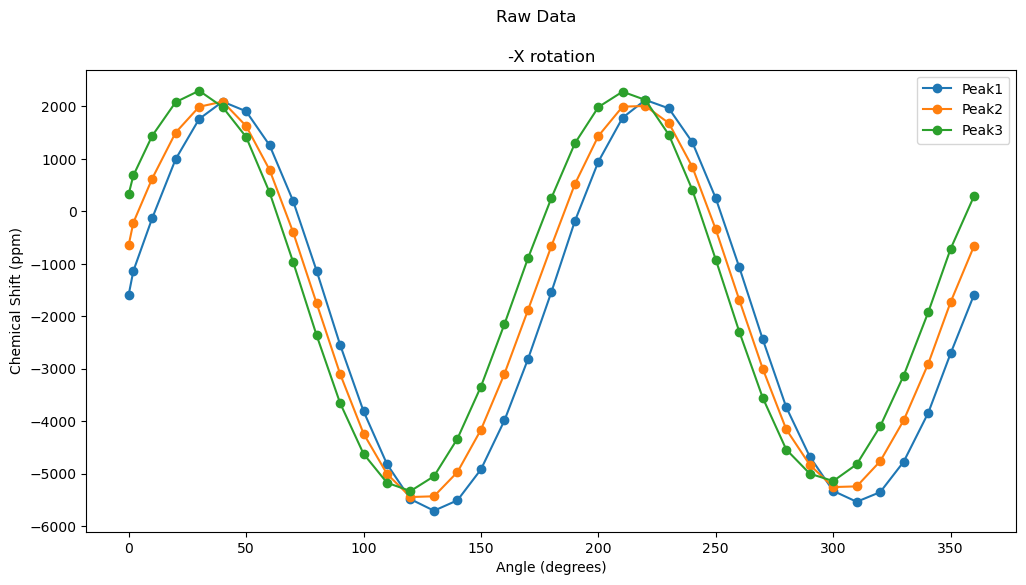

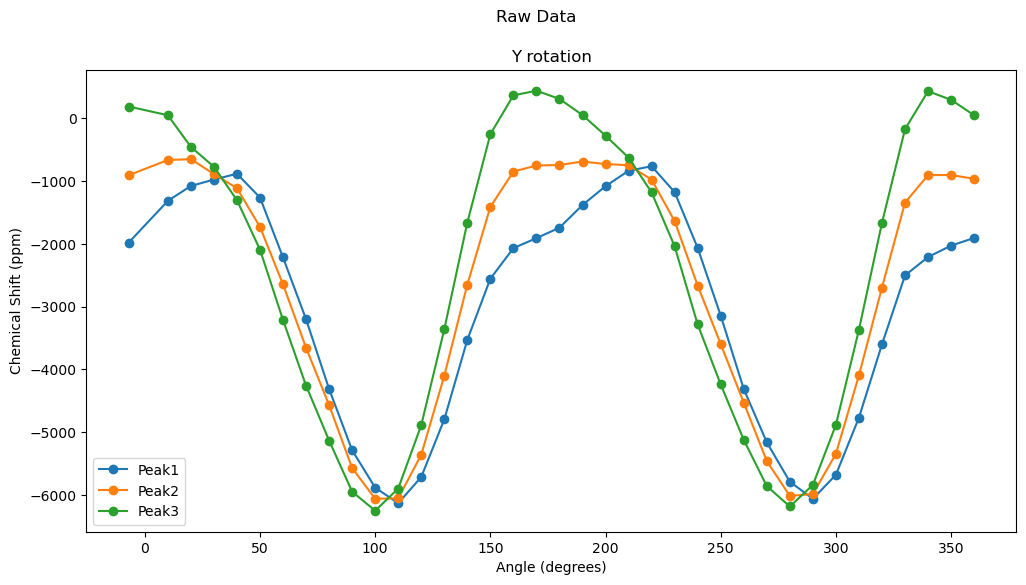

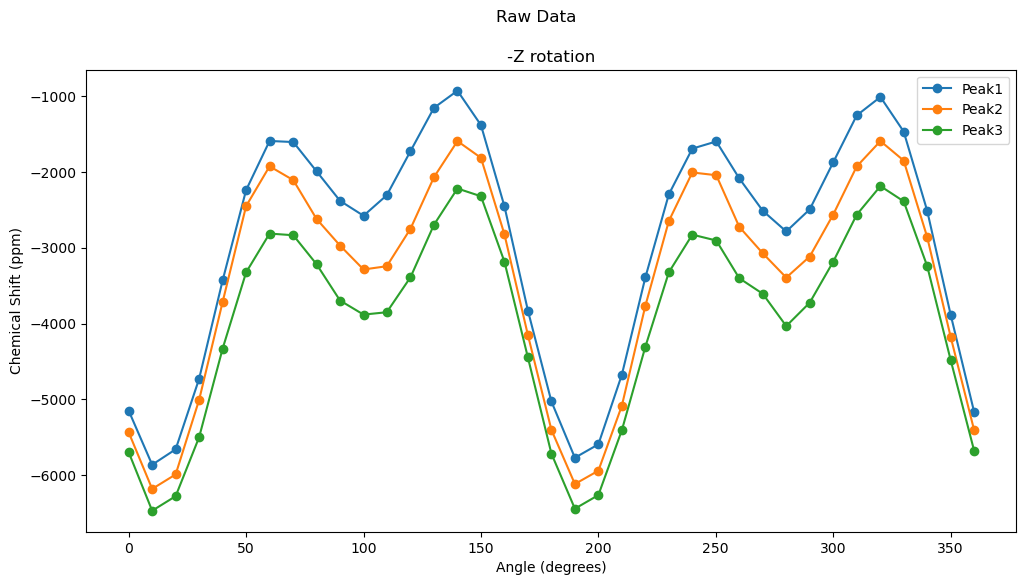

In [2]:
titles = ['-X rotation', 'Y rotation', '-Z rotation']
df = [0]*3

    
df[0] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_X_Rot', skiprows=[1])
df[1] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Y_Rot', skiprows=[1])
df[2] = pd.read_excel('//home/shiva/WMU/PhD/Scripts/phd_project/Python/NMR/Data_exp/B_Rotation_Plot.xlsx', sheet_name='(-)8HQ_Z_Rot', skiprows=[1])
for i in range(3):

    df[i].Cluster1Peak0 = df[i].Cluster1Peak0*w0
    df[i].Cluster1Peak1 = df[i].Cluster1Peak1*w0
    df[i].Cluster1Peak2 = df[i].Cluster1Peak2*w0

    # print(df[i].Cluster1Peak1)
    plt.figure(figsize=(12, 6))


    plt.plot(df[i].Angle, df[i].Cluster1Peak0, label = 'Peak1', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak1, label = 'Peak2', marker='o')
    plt.plot(df[i].Angle, df[i].Cluster1Peak2, label = 'Peak3', marker='o')
    plt.suptitle('Raw Data')
    plt.xlabel('Angle (degrees)')
    plt.ylabel('Chemical Shift (ppm)')
    plt.title(titles[i])
    plt.legend()
    plt.show()

In [5]:
df_Q = [0]*3
for i in range(3):
    df_Q[i] =  -2*df[i].Cluster1Peak1 + df[i].Cluster1Peak0 + df[i].Cluster1Peak2 #from equation in Rotating Frame hamiltonian_32_52 word document
  

┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 7.01e+06 (chi2/ndof = 212419.8)│              Nfcn = 130              │
│ EDM = 7.54e-19 (Goal: 0.0002)    │            time = 0.1 sec            │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────┴─────────────┴────────────┘
┌───┬──────┬───────────┬───────────┬────────────┬────────────┬─────────┬─────────┬──

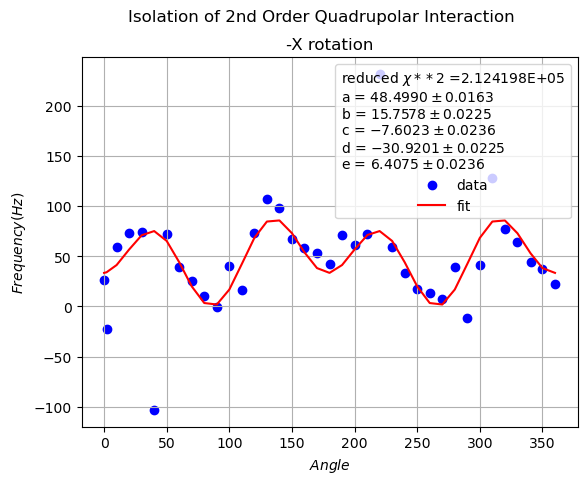

a = 48.49894904233501
b = 15.757770897722649
c = -7.602257989030655
d = -30.920051737604936
e = 6.407479231814237
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 2.414e+07 (chi2/ndof = 754442.0)│              Nfcn = 157              │
│ EDM = 5.59e-18 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴─────────

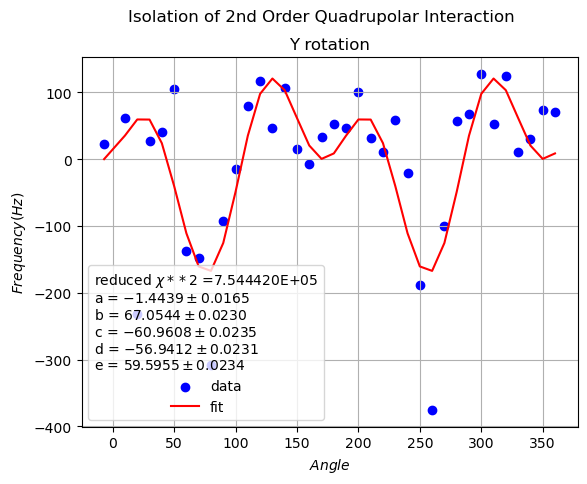

a = -1.443883430213725
b = 67.05429078220367
c = -60.96087528583434
d = -56.9411725757277
e = 59.59558694105792
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 4.85e+07 (chi2/ndof = 1515574.2)│              Nfcn = 159              │
│ EDM = 1.13e-17 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────────────┤
│  Covariance   │     Hesse ok     │ Accurate  │  Pos. def.  │ Not forced │
└───────────────┴──────────────────┴───────────

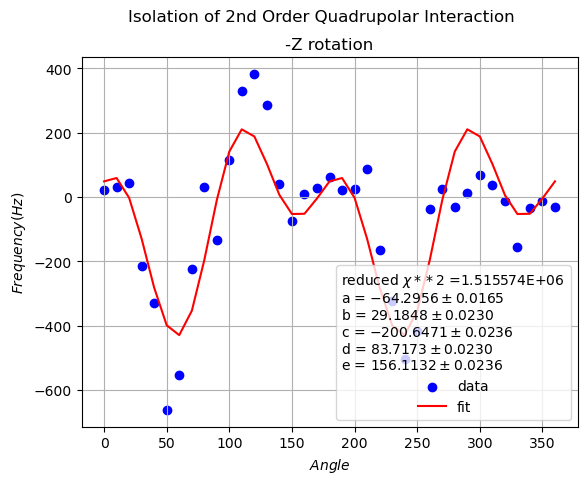

a = -64.2955071169319
b = 29.18468873021985
c = -200.64708809817677
d = 83.71738531473686
e = 156.11322877064853


In [7]:
m_Q = [0]*3

for i in range(3):
    least_squares = LeastSquares(df[i].Angle, df_Q[i], 0.1,fourier5)
    
    m_Q[i] = Minuit(least_squares, a = 1, b = 1, c= 1, d = 0, e = 1).migrad()
    # m[i] = m[i].scan(ncall = 50)

    # m[i].migrad()  # finds minimum of least_squares function
    m_Q[i].hesse()   # accurately computes uncertainties
    
    fit_info = [
        f"reduced $\\chi**2$ ={(m_Q[i].fval / (len(df[i].Angle) - m_Q[i].nfit)):5E}"
    ]
    # print(fit_info)
    
    for p, v, e in zip(m_Q[i].parameters, m_Q[i].values, m_Q[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    print(m_Q[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].Angle, df_Q[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier5(df[i].Angle, *m_Q[i].values), label="fit", color = 'red')
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # plt.title(titles[i] +'\n'r'$Fitting\ of\ H^1_{CSA} = A + B(cos2\theta )+ C(sin2\theta)$')
    plt.suptitle('Isolation of 2nd Order Quadrupolar Interaction')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    plt.grid()
    plt.show()
    
    for key, value in zip(m_Q[i].parameters, m_Q[i].values):
        print(f"{key} = {value}")

In [21]:
a_Q = [0]*3; 
b_Q = [0]*3; 
c_Q = [0]*3; 
d_Q = [0]*3
e_Q = [0]*3

par_Q = [a_Q, b_Q, c_Q, d_Q, e_Q]
for i in range(0,3):
    for k in range(len(par_Q)):
        par_Q[k][i] = m_Q[i].values[k]

Dx = d_Q[0]*wX*72;
Ex = e_Q[0]*wX*72;

Dy = d_Q[1]*wX*72;
Ey = e_Q[1]*wX*72;

Dz = d_Q[2]*wX*72;
Ez = e_Q[2]*wX*72;

#solving equations for Isolation of 2nd order Uadrupolar Interaction
gyz2 = (Dx + np.sqrt(Dx**2+Ex**2))/(2*102/4);
gyz_q = -np.sqrt(gyz2); 
gzzmgyy = (4*Ex/102)*(1/gyz_q);

# print(Dx)

gxz2 = (Dy + np.sqrt(Dy**2+Ey**2))/(2*102/4);
gxz_q = np.sqrt(gxz2);
gzzmgxx = -(4*Ey/102)*(1/gxz_q);

# print(Gxz_Q)

gxy2 = (Dz + np.sqrt(Dz**2+Ez**2))/(2*102/4);
gxy_q = np.sqrt(gxy2);
gxxmgyy = (4*Ez/102)*(1/gxy_q);

# print(Gxy_Q)

gzz1 = (gzzmgyy + gzzmgxx)/3
gyy1 = gzz1 -gzzmgyy
gxx1 = gzz1 -gzzmgxx

gxx2 = (gxxmgyy-gzzmgxx)/3
gzz2 = gxx2+gzzmgxx
gyy2 = gxx2-gxxmgyy

gyy3 = -(gzzmgyy + gxxmgyy)/3
gzz3 = gyy3 + gzzmgyy
gxx3 = gyy3 + gxxmgyy

gxx_q = (gxx1+gxx2+gxx3)/3;
gyy_q = (gyy1+gyy2+gyy3)/3;
gzz_q = (gzz1+gzz2+gzz3)/3;

# print(Gxx, Gyy, Gzz)

QXG_f = np.zeros((3, 3))                                #Fit tensor
QXG_f[0,0]=gxx_q; QXG_f[0,1]=gxy_q; QXG_f[0,2]=gxz_q;
QXG_f[1,0]=gxy_q; QXG_f[1,1]=gyy_q; QXG_f[1,2]=gyz_q;
QXG_f[2,0]=gxz_q; QXG_f[2,1]=gyz_q; QXG_f[2,2]=gzz_q;

QXG_f = -QXG_f;
print(gxx1, gxx2, gxx3, gyy1, gyy2, gyy3, gzz1, gzz2, gzz3)
print('Calculated Quad Tensor:\n',QXG_f)

172625.68293367003 236002.08596535723 299378.4889970444 44028.624745326524 -82724.18131804783 -19347.77828636066 -216654.30767899656 -153277.90464730936 -280030.7107106837
Calculated Quad Tensor:
 [[-236002.08596536 -266291.73566539  -83231.52638151]
 [-266291.73566539   19347.77828636   13363.19938812]
 [ -83231.52638151   13363.19938812  216654.307679  ]]


In [11]:
HQ1_freq_3212 = [0]*3
HQ1_freq_1212 = [0]*3
HQ1_freq_1232 = [0]*3


HQ2_freq_3212 = [0]*3
HQ2_freq_1212 = [0]*3
HQ2_freq_1232 = [0]*3

for i in range (3):
    ang = df[i].Angle*np.pi/180.
    atheta = [-ang, ang,np.pi/2 ] #-x, y, -z rotation
    aphi = [np.pi/2, 0, -ang]

    theta = atheta[i] 
    phi = aphi[i]
    ct = np.cos(theta); st = np.sin(theta); s2t = 2*ct*st; c2t = ct*ct-st*st;
    cp = np.cos(phi); sp = np.sin(phi); s2p = 2*cp*sp; c2p = cp*cp-sp*sp;

    R2m2Q, R2m1Q, R20Q, R2p1Q, R2p2Q = Quad(QXG_f,ct, st, s2t, c2t, cp ,sp ,c2p ,s2p)

            
    HQ1 = 1/(2*Ispin*(2*Ispin-1))*R20Q
    HQ2a= (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m2Q*R2p2Q)/wX                         
    HQ2b = (0.5/(2*Ispin*(2*Ispin-1))**2)*(R2m1Q*R2p1Q)/wX


    HQ1_freq_3212[i] = 6*(np.real(HQ1))               # 3/2 <-> 1/2
    HQ1_freq_1212[i] = 0*(np.real(HQ1))               # 1/2 <-> -1/2
    HQ1_freq_1232[i] = -6*(np.real(HQ1))              #-1/2   <-> -3/2       
    
    HQ2_freq_3212[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       # 3/2 <-> 1/2
    HQ2_freq_1212[i] = 6*np.real(HQ2a) + 12*np.real(HQ2b)        # 1/2 <-> -1/2
    HQ2_freq_1232[i] = 0*np.real(HQ2a) + -12*np.real(HQ2b)       #-1/2   <-> -3/2  

┌───┬────────────────────────────┐
│   │        a        b        c │
├───┼────────────────────────────┤
│ a │        1  -0.0725 -0.00313 │
│ b │  -0.0725        1 -0.00333 │
│ c │ -0.00313 -0.00333        1 │
└───┴────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.737e+06 (chi2/ndof = 106783.0)│              Nfcn = 78               │
│ EDM = 1.1e-17 (Goal: 0.0002)     │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──────────────────┼───────────┬─────────────┬────

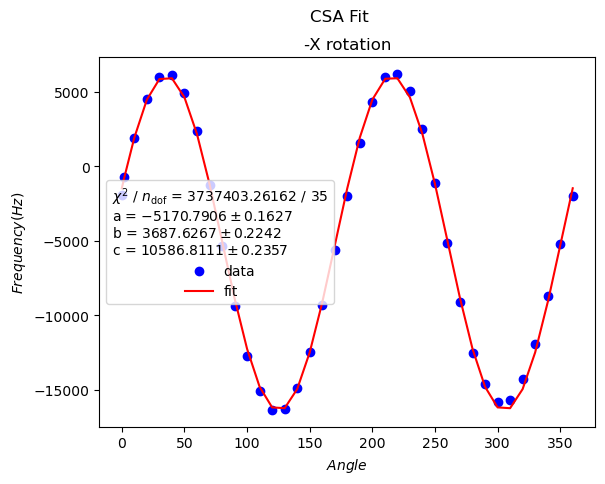

a = -5170.790606984767
b = 3687.6268025217964
c = 10586.8110408369
┌───┬─────────────────────────┐
│   │       a       b       c │
├───┼─────────────────────────┤
│ a │       1 -0.0365  0.0089 │
│ b │ -0.0365       1  0.0124 │
│ c │  0.0089  0.0124       1 │
└───┴─────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 8.492e+07 (chi2/ndof = 2497727.2)│              Nfcn = 87               │
│ EDM = 1.17e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           │
├───────────────┬──

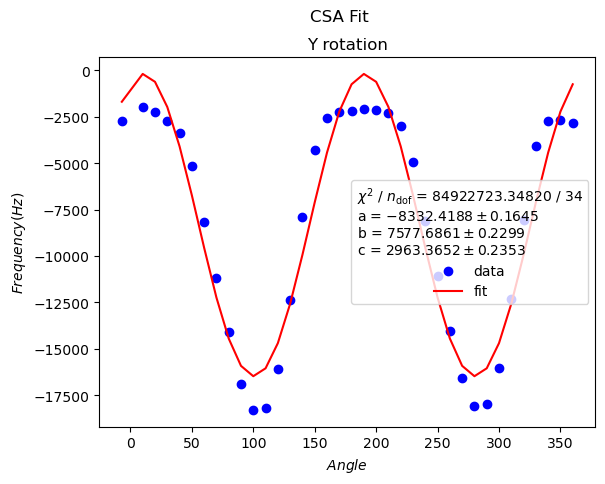

a = -8332.41930674168
b = 7577.686590384379
c = 2963.3653305458674
┌───┬────────────────────────────┐
│   │        a        b        c │
├───┼────────────────────────────┤
│ a │        1  -0.0375  0.00018 │
│ b │  -0.0375        1 0.000102 │
│ c │  0.00018 0.000102        1 │
└───┴────────────────────────────┘
┌─────────────────────────────────────────────────────────────────────────┐
│                                Migrad                                   │
├──────────────────────────────────┬──────────────────────────────────────┤
│ FCN = 3.167e+08 (chi2/ndof = 9315895.5)│              Nfcn = 93               │
│ EDM = 7.18e-16 (Goal: 0.0002)    │                                      │
├──────────────────────────────────┼──────────────────────────────────────┤
│          Valid Minimum           │        No Parameters at limit        │
├──────────────────────────────────┼──────────────────────────────────────┤
│ Below EDM threshold (goal x 10)  │           Below call limit           

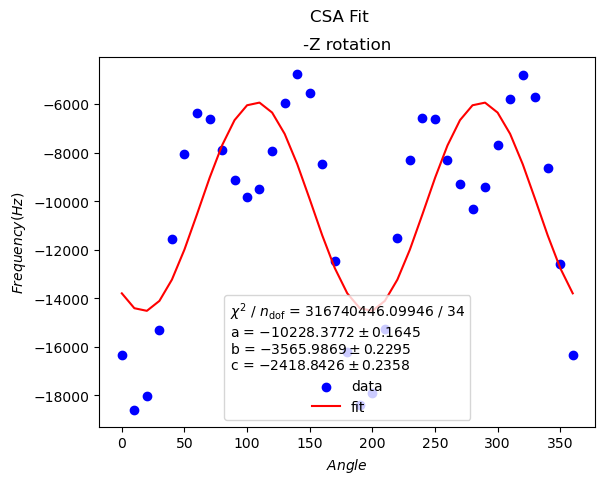

a = -10228.377352036463
b = -3565.9869211902055
c = -2418.842586239748


In [14]:
HQ2_freq_sum = [0]*3
csa = [0]*3
m_csa = [0]*3
freq_sum = [0]*3

for i in range(3):
    HQ2_freq_sum[i] = HQ2_freq_3212[i] + HQ2_freq_1212[i] + HQ2_freq_1232[i]
    freq_sum[i] = df[i].Cluster1Peak0 + df[i].Cluster1Peak1 + df[i].Cluster1Peak2
    csa[i] = freq_sum[i] - HQ2_freq_sum[i]  
    least_squares = LeastSquares(df[i].Angle, csa[i], 1,fourier3)
    
    m_csa[i] = Minuit(least_squares, a = -1, b = -1, c= -1)
    # m[i] = m[i].scan(ncall = 50)

    m_csa[i].migrad()  # finds minimum of least_squares function
    m_csa[i].hesse()   # accurately computes uncertainties
    fit_info = [
        f"$\\chi^2$ / $n_\\mathrm{{dof}}$ = {m_csa[i].fval:.5f} / {len(df[i].Angle) - m_csa[i].nfit}",
    ]
    # print(fit_info)
    

    for p, v, e in zip(m_csa[i].parameters, m_csa[i].values, m_csa[i].errors):
        fit_info.append(f"{p} = ${v:.4f} \\pm {e:.4f}$")

    corr_mat = (m_csa[i].covariance.correlation())
    print(corr_mat)
    print(m_csa[i].migrad())
    # plt.imshow(corr_mat, cmap='coolwarm')
    
    # draw data and fitted line
    plt.scatter(df[i].Angle, csa[i], label="data", color = 'blue')
    plt.plot(df[i].Angle, fourier3(df[i].Angle, *m_csa[i].values), label="fit", color = 'red')
    
    plt.xlabel(r'$Angle$')
    plt.ylabel(r'$Frequency (Hz)$')
    # Titles
    plt.suptitle('CSA Fit')
    plt.title(titles[i])
    plt.legend(title="\n".join(fit_info))
    # plt.grid()
    plt.show()
    
    for key, value in zip(m_csa[i].parameters, m_csa[i].values):
        print(f"{key} = {value}")

a_csa = [0]*3; 
b_csa = [0]*3; 
c_csa = [0]*3; 

par_csa = [a_csa, b_csa, c_csa]

for i in range(0,3):
    for k in range(len(par_csa)):
        par_csa[k][i] = m_csa[i].values[k]


In [16]:
A= [0]*3
B = [0]*3
C = [0]*3
A_HCSA1 = [0]*3
B_HCSA1 = [0]*3
X = [0]*3


for i in range(0,3):

    A_HCSA1[i] = np.array([[3/2, 3/2], [3/2, -3/2]])
    B_HCSA1[i] = np.array([a_csa[i], b_csa[i]])
    X[i] = np.linalg.inv(A_HCSA1[i]).dot(B_HCSA1[i])
    

gzz_csa1 = X[0][0]
gyy_csa1= X[0][1]
gyz_csa = -c_csa[0]/3

gzz_csa2 = X[1][0]
gxx_csa2 = X[1][1]
gxz_csa = c_csa[1]/3

gxx_csa3 = X[2][0]
gyy_csa3 = X[2][1]
gxy_csa = -c_csa[2]/3

gxx_csa = np.mean([gxx_csa2, gxx_csa3])
gyy_csa = np.mean([gyy_csa1, gyy_csa3])
gzz_csa = np.mean([gzz_csa1, gzz_csa2])




CsaQXG_f = np.zeros((3, 3))                                #Tensor from fitting
CsaQXG_f[0,0]=gxx_csa; CsaQXG_f[0,1]=gxy_csa; CsaQXG_f[0,2]=gxz_csa;
CsaQXG_f[1,0]=gxy_csa; CsaQXG_f[1,1]=gyy_csa; CsaQXG_f[1,2]=gyz_csa;
CsaQXG_f[2,0]=gxz_csa; CsaQXG_f[2,1]=gyz_csa; CsaQXG_f[2,2]=gzz_csa;

print('Calculated CSA Tensor:\n',CsaQXG_f)


print(tabulate([['gxx_q',gxx_q], ['gyy_q',gyy_q], ['gzz_q',gzz_q], ['gxy_q',gxy_q], ['gyz_q',gyz_q], ['gxz_q',gxz_q],['gxx_csa',gxx_csa], ['gyy_csa',gyy_csa], ['gzz_csa',gzz_csa], ['gxy_csa',gxy_csa], ['gyz_csa',gyz_csa], ['gxz_csa',gxz_csa]]))

Calculated CSA Tensor:
 [[-4950.74502839   806.28086208   987.78844352]
 [  806.28086208 -2586.80130673 -3528.93701361]
 [  987.78844352 -3528.93701361  -372.98275347]]
-------  -----------
gxx_q     236002
gyy_q     -19347.8
gzz_q    -216654
gxy_q     266292
gyz_q     -13363.2
gxz_q      83231.5
gxx_csa    -4950.75
gyy_csa    -2586.8
gzz_csa     -372.983
gxy_csa      806.281
gyz_csa    -3528.94
gxz_csa      987.788
-------  -----------


In [17]:
eigenvalues, eigenvectors = np.linalg.eig(QXG_f)
D_quad = np.diag(eigenvalues)
print('Diagonalized Quadrupolar Tensor:\n', D_quad)
sorted_eigenvalues = sorted(eigenvalues, key=abs)


print('Sorted Eigenvalues of Quadrupolar diagonal matrix:\n', sorted_eigenvalues) #See Haberlen convention for details [ref: Single-Crystal NMR Spectroscopy – Method Development and Application to Inorganic Solids]

Gzz_q = sorted_eigenvalues[2]
Gyy_q = sorted_eigenvalues[1]
Gxx_q = sorted_eigenvalues[0]

print('Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): \n', Gzz_q, Gyy_q, Gxx_q)

print('================================================================================================')

eigenvalues, eigenvectors = np.linalg.eig(CsaQXG_f)
D_csa = np.diag(eigenvalues)

print('Diagonalized CSA Tensor:\n',D_csa)
csa_avg = np.mean(eigenvalues)

sorted_eigenvalues = sorted((eigenvalues - csa_avg), key = abs) #See Haberlen convention for details

print('Sorted Eigenvalues (Eigenvalue - isotropic CS)  of CSA diagonal matrix:\n',sorted_eigenvalues )

Gzz_csa = sorted_eigenvalues[2] + csa_avg
Gxx_csa = sorted_eigenvalues[1] + csa_avg 
Gyy_csa = sorted_eigenvalues[0] + csa_avg

print('CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : \n', Gzz_csa, Gyy_csa, Gxx_csa)

Diagonalized Quadrupolar Tensor:
 [[-410094.10587786       0.               0.        ]
 [      0.          146826.14708212       0.        ]
 [      0.               0.          263267.95879575]]
Sorted Eigenvalues of Quadrupolar diagonal matrix:
 [146826.1470821151, 263267.9587957481, -410094.10587786336]
Quad Tensors Gzz_q, Gyy_q, Gxx_q (According to |Qzz| >= |Qyy| >= |Qxx|): 
 -410094.10587786336 263267.9587957481 146826.1470821151
Diagonalized CSA Tensor:
 [[-6309.76232683     0.             0.        ]
 [    0.         -3833.91501123     0.        ]
 [    0.             0.          2233.14824947]]
Sorted Eigenvalues (Eigenvalue - isotropic CS)  of CSA diagonal matrix:
 [-1197.0719817019271, -3672.919297297393, 4869.991278999321]
CSA Tensors Gzz_csa, Gyy_csa, Gxx_csa (According to |Gzz - isotropic| >= |Gxx - isotropic| >= |Gyy - isotropic|) : 
 2233.148249470109 -3833.9150112311395 -6309.762326826605


In [19]:
# #for CSA
# Siso_fit = (gxx_csa + gyy_csa + gzz_csa)/3
# Siso_ppm_fit = Siso_fit/w0
# delta_fit = gzz_csa/w0 - Siso_ppm_fit
# eta_fit = (gxx_csa - gyy_csa)/w0/delta_fit

# #for Quadrupolar
# CQ_fit = gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
# Qeta_fit = (gxx_q - gyy_q)/gzz_q

# table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
# print(tabulate(table, headers=['Qauntity', 'Fit Value']))

#****************************************************************

#using Diagonalized values 
# for CSA
Siso_fit = (Gxx_csa + Gyy_csa + Gzz_csa)/3
Siso_ppm_fit = Siso_fit/w0
delta_fit = Gzz_csa/w0 - Siso_ppm_fit
eta_fit = (Gyy_csa - Gxx_csa)/w0/delta_fit

#for Quadrupolar
CQ_fit = Gzz_q*(2*Ispin*(2*Ispin - 1))/10**6
Qeta_fit = (Gxx_q - Gyy_q)/Gzz_q

table = [['Siso (ppm)',Siso_ppm_fit ],['delta (ppm)', delta_fit],  ['eta', eta_fit],  ['CQ (MHz)', CQ_fit], ['Qeta', Qeta_fit ]]
print(tabulate(table, headers=['Qauntity', 'Fit Value']))

Qauntity       Fit Value
-----------  -----------
Siso (ppm)    -13.6943
delta (ppm)    25.2921
eta             0.508388
CQ (MHz)       -2.46056
Qeta            0.283939
